In [1]:
!mamba install pandas

mambajs 0.19.13

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas
Channels: emscripten-forge, conda-forge

Solving environment...
Solving took 1.9575 seconds
  Name                          Version                       Build                         Channel                       
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
+ pandas                        3.0.2                         np22py313h9d9dc1e_0           emscripten-forge              
+ python-tzdata                 2026.2                        pyhd8ed1ab_0                  conda-forge                   
- pip                           25.3                          pyh145f28c_0                  conda-forge                   


In [2]:
!mamba install seaborn

mambajs 0.19.13

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas, seaborn
Channels: emscripten-forge, conda-forge

Solving environment...
Solving took 0.9686000000238418 seconds
  Name                          Version                       Build                         Channel                       
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
+ patsy                         1.0.2                         py313h1804a44_1               emscripten-forge              
+ seaborn                       0.13.2                        hd8ed1ab_3                    conda-forge                   
+ seaborn-base                  0.13.2                        pyhd8ed1ab_3                  conda-forge                   
+ statsmodels                   0.14.6                        np22py313h3cf259a_1           emscripten-forge              


In [3]:
!mamba install scikit-learn

mambajs 0.19.13

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas, seaborn, scikit-learn
Channels: emscripten-forge, conda-forge

Solving environment...
Solving took 0.874 seconds
  Name                          Version                       Build                         Channel                       
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
+ brotli-python                 1.2.0                         py313h33caa6c_0               emscripten-forge              
+ certifi                       2026.4.22                     pyhd8ed1ab_0                  conda-forge                   
+ charset-normalizer            3.4.7                         pyhd8ed1ab_0                  conda-forge                   
+ idna                          3.13                          pyhcf101f3_0                  conda-forge                   
+ joblib                        1.5.3    

In [4]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

df = pd.read_csv("cardio_train.csv", sep=";")
df.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [5]:
# Summarize the dataset
# Data types & non-null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB


In [6]:
# How many rows/columns are in the dataset?
# What are the column names?
df.shape
print("Shape of dataset:", df.shape)
print("Columns:\n", df.columns)

Shape of dataset: (70000, 13)
Columns:
 Index(['id', 'age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo',
       'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio'],
      dtype='str')


In [7]:
# Check for missing values
df.isnull().sum()

id             0
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64

In [8]:
# Convert age from days to years, rounding
df["age_years"] = df["age"] / 365
df["age_years"] = df["age_years"].round(1)

In [9]:
# Create feature for BMI (weight/(height/100))^2
df["bmi"] = df["weight"] / (df["height"]/100)**2

In [10]:
# Summary statistics
df.describe()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years,bmi
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,49972.419900,19468.865814,1.349571,164.359229,74.205690,128.817286,96.630414,1.366871,1.226457,0.088129,0.053771,0.803729,0.499700,53.339486,27.556513
std,28851.302323,2467.251667,0.476838,8.210126,14.395757,154.011419,188.472530,0.680250,0.572270,0.283484,0.225568,0.397179,0.500003,6.759534,6.091511
min,0.000000,10798.000000,1.000000,55.000000,10.000000,-150.000000,-70.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,29.600000,3.471784
25%,25006.750000,17664.000000,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,48.400000,23.875115
50%,50001.500000,19703.000000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,54.000000,26.374068
75%,74889.250000,21327.000000,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000,58.400000,30.222222
max,99999.000000,23713.000000,2.000000,250.000000,200.000000,16020.000000,11000.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000,65.000000,298.666667


In [11]:
# Check blood pressure for any outlier data
df[["ap_hi", "ap_lo"]].describe()

,ap_hi,ap_lo
count,70000.000000,70000.000000
mean,128.817286,96.630414
std,154.011419,188.472530
min,-150.000000,-70.000000
25%,120.000000,80.000000
50%,120.000000,80.000000
75%,140.000000,90.000000
max,16020.000000,11000.000000


In [12]:
# Check height and weight for outlier data
df[["height", "weight"]].describe()

,height,weight
count,70000.000000,70000.000000
mean,164.359229,74.205690
std,8.210126,14.395757
min,55.000000,10.000000
25%,159.000000,65.000000
50%,165.000000,72.000000
75%,170.000000,82.000000
max,250.000000,200.000000


In [13]:
# How many patients have cardiovascular disease?
df["cardio"].value_counts()

cardio
0    35021
1    34979
Name: count, dtype: int64

In [14]:
# Proportion of how many patients have cardiovascular disease
df["cardio"].value_counts(normalize=True)

cardio
0    0.5003
1    0.4997
Name: proportion, dtype: float64

In [15]:
# Lifestyle factors counts
df["smoke"].value_counts()
df["alco"].value_counts()
df["active"].value_counts()

print("Smoking:\n", df["smoke"].value_counts(), "\n")
print("Alcohol:\n", df["alco"].value_counts(), "\n")
print("Physical Activity:\n", df["active"].value_counts())

Smoking:
 smoke
0    63831
1     6169
Name: count, dtype: int64 

Alcohol:
 alco
0    66236
1     3764
Name: count, dtype: int64 

Physical Activity:
 active
1    56261
0    13739
Name: count, dtype: int64


In [16]:
# Check categorical health indicators
df["cholesterol"].value_counts()
df["gluc"].value_counts()

print("Cholesterol:\n", df["cholesterol"].value_counts(), "\n")
print("Glucose:\n", df["gluc"].value_counts())

Cholesterol:
 cholesterol
1    52385
2     9549
3     8066
Name: count, dtype: int64 

Glucose:
 gluc
1    59479
3     5331
2     5190
Name: count, dtype: int64


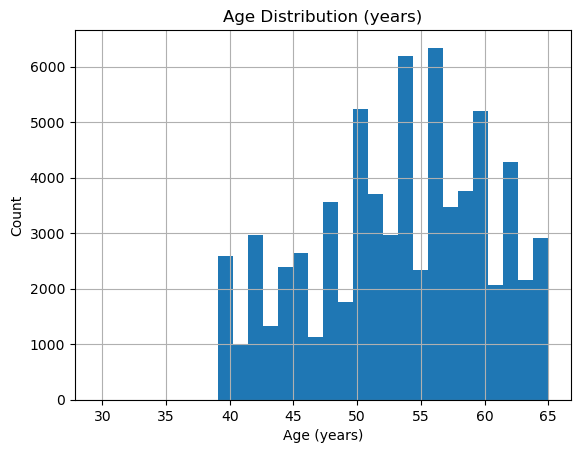

In [17]:
# Visualizations
# Age histogram

df["age_years"].hist(bins=30)
plt.title("Age Distribution (years)")
plt.xlabel("Age (years)")
plt.ylabel("Count")
plt.show()

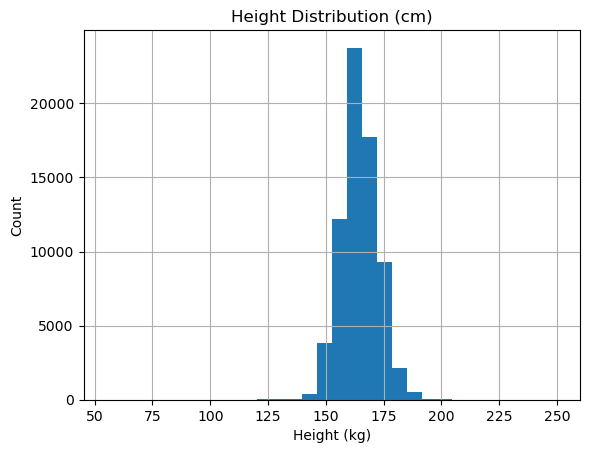

In [18]:
# Height histogram

df["height"].hist(bins=30)
plt.title("Height Distribution (cm)")
plt.xlabel("Height (kg)")
plt.ylabel("Count")
plt.show()

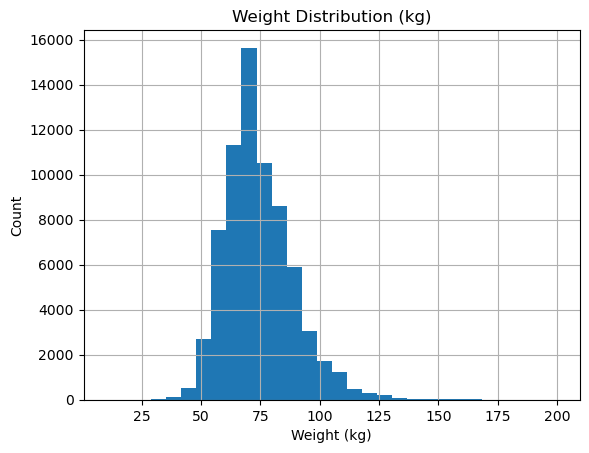

In [19]:
# Weight histogram

df["weight"].hist(bins=30)
plt.title("Weight Distribution (kg)")
plt.xlabel("Weight (kg)")
plt.ylabel("Count")
plt.show()

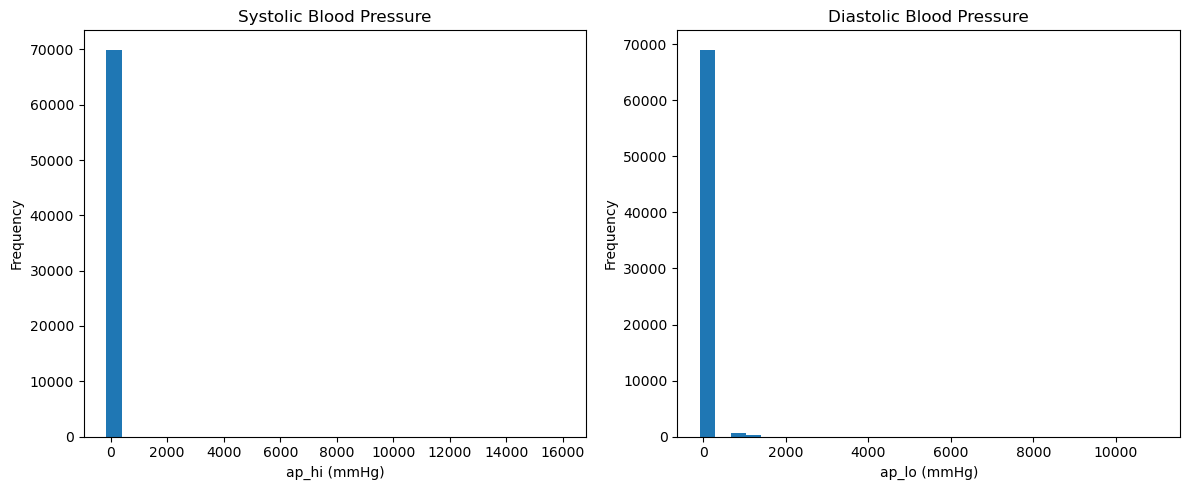

In [20]:
# Blood pressure histograms

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Systolic BP (ap_hi)
axes[0].hist(df["ap_hi"], bins=30)
axes[0].set_title("Systolic Blood Pressure")
axes[0].set_xlabel("ap_hi (mmHg)")
axes[0].set_ylabel("Frequency")

#Diastolic BP (ap_lo)
axes[1].hist(df["ap_lo"], bins=30)
axes[1].set_title("Diastolic Blood Pressure")
axes[1].set_xlabel("ap_lo (mmHg)")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

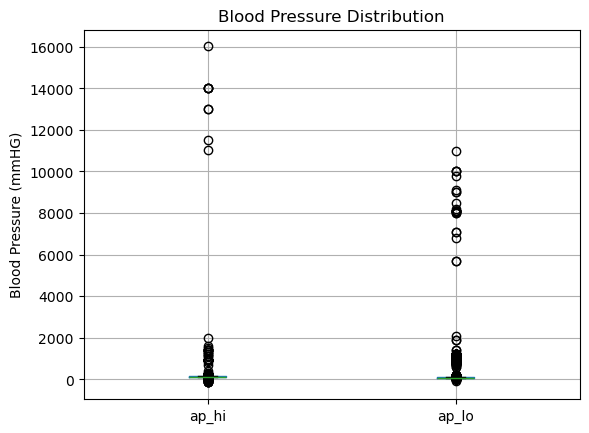

In [21]:
# Blood Pressure Boxplots to detect outliers

df.boxplot(column=["ap_hi", "ap_lo"])

plt.title("Blood Pressure Distribution")
plt.ylabel("Blood Pressure (mmHG)")

plt.show()

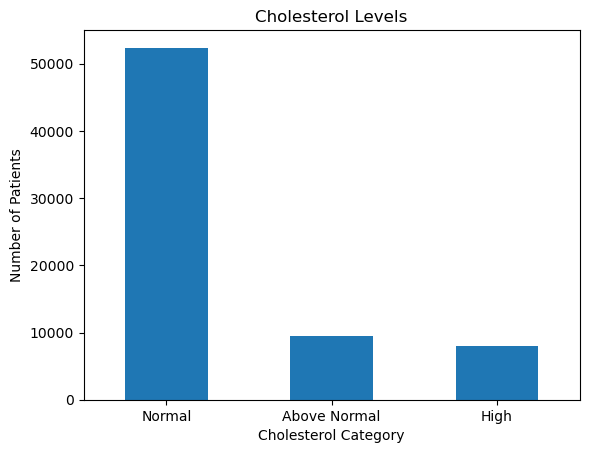

In [22]:
# Cholesterol Bar Chart

chol_labels = {1: "Normal", 2: "Above Normal", 3: "High"}
df["cholesterol"].map(chol_labels).value_counts().plot(kind="bar")

plt.title("Cholesterol Levels")
plt.xlabel("Cholesterol Category")
plt.ylabel("Number of Patients")
plt.xticks(rotation=0)

plt.show()

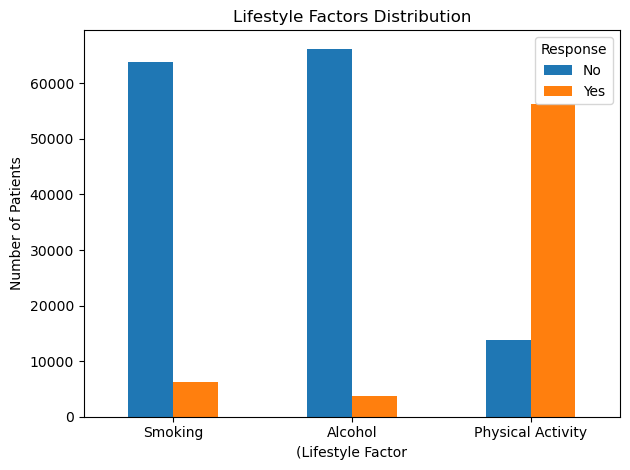

In [23]:
# Lifestyle factors boxplot

# Rename columns for readability
df_lifestyle = df[["smoke", "alco", "active"]].copy()
df_lifestyle.columns = ["Smoking", "Alcohol", "Physical Activity"]

# Count values (0 and 1) for each column
counts = df_lifestyle.apply(pd.Series.value_counts)

# Rename index for clarity
counts.index = ["No", "Yes"]

# Plot
counts.T.plot(kind="bar")

plt.title("Lifestyle Factors Distribution")
plt.xlabel("(Lifestyle Factor")
plt.ylabel("Number of Patients")
plt.xticks(rotation=0)

plt.legend(title="Response")

plt.tight_layout()
plt.show()

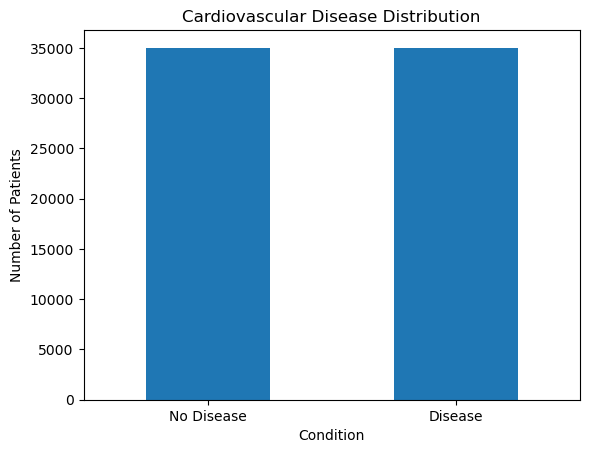

In [24]:
# Target variable distribution (cardiovascular disease)

cardio_labels = {0: "No Disease", 1: "Disease"}

df["cardio"].map(cardio_labels).value_counts().plot(kind="bar")

plt.title("Cardiovascular Disease Distribution")
plt.xlabel("Condition")
plt.ylabel("Number of Patients")

plt.xticks(rotation=0)
plt.show()

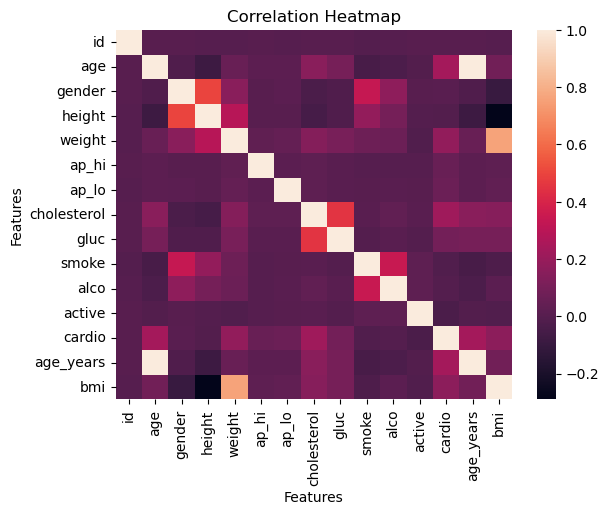

In [25]:
# Correlation Heatmap

corr = df.corr()

sns.heatmap(corr, annot=False)

plt.title("Correlation Heatmap")
plt.xlabel("Features")
plt.ylabel("Features")

plt.show()

In [26]:
# Step 2: Data Cleaning and Imputation

# Identify & mark invalid values as NaN
# Blood pressure (physiological limits)
df.loc[(df["ap_hi"] < 50) | (df["ap_hi"] > 250), "ap_hi"] = np.nan
df.loc[(df["ap_lo"] < 30) | (df["ap_lo"] > 200), "ap_lo"] = np.nan

# Height (adult range)
df.loc[(df["height"] < 120) | (df["height"] > 220), "height"] = np.nan

# Weight (adult range)
df.loc[(df["weight"] < 30) | (df["weight"] > 200), "weight"] = np.nan

df.info()


<class 'pandas.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       69947 non-null  float64
 4   weight       69993 non-null  float64
 5   ap_hi        69772 non-null  float64
 6   ap_lo        68994 non-null  float64
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
 13  age_years    70000 non-null  float64
 14  bmi          70000 non-null  float64
dtypes: float64(6), int64(9)
memory usage: 8.0 MB


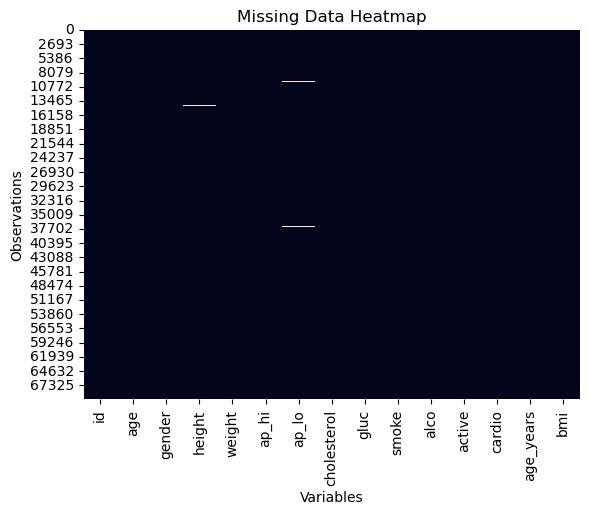

In [27]:
# Missing data heatmap

sns.heatmap(df.isnull(), cbar=False)

plt.title("Missing Data Heatmap")
plt.xlabel("Variables")
plt.ylabel("Observations")

plt.show()

In [28]:
# Imputation - mean for continuous data

df["ap_hi"].fillna(df["ap_hi"].mean())
df["ap_lo"].fillna(df["ap_lo"].mean())
df["height"].fillna(df["height"].mean())
df["weight"].fillna(df["weight"].mean())

# mode for categorical data
df["cholesterol"].fillna(df["cholesterol"].mode()[0])
df["gluc"].fillna(df["gluc"].mode()[0])
df["smoke"].fillna(df["smoke"].mode()[0])
df["alco"].fillna(df["alco"].mode()[0])
df["active"].fillna(df["active"].mode()[0])

# Re-display summary statistics
df.describe()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years,bmi
count,70000.000000,70000.000000,70000.000000,69947.000000,69993.000000,69772.000000,68994.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,49972.419900,19468.865814,1.349571,164.414056,74.211054,127.001820,81.380062,1.366871,1.226457,0.088129,0.053771,0.803729,0.499700,53.339486,27.556513
std,28851.302323,2467.251667,0.476838,7.925985,14.386312,17.096568,9.703481,0.680250,0.572270,0.283484,0.225568,0.397179,0.500003,6.759534,6.091511
min,0.000000,10798.000000,1.000000,120.000000,30.000000,60.000000,30.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,29.600000,3.471784
25%,25006.750000,17664.000000,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,48.400000,23.875115
50%,50001.500000,19703.000000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,54.000000,26.374068
75%,74889.250000,21327.000000,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000,58.400000,30.222222
max,99999.000000,23713.000000,2.000000,207.000000,200.000000,240.000000,190.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000,65.000000,298.666667


In [29]:
# Step 3: Detect outliers

# Function to detect outliers using IQR
def detect_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]

    print(f"{column}: {len(outliers)} outliers")
    return lower_bound, upper_bound

# Apply to key continuous variables
cols = ["age_years", "height", "weight", "ap_hi", "ap_lo"]

bounds = {}
for col in cols:
    bounds[col] = detect_outliers(df, col)

age_years: 4 outliers
height: 466 outliers
weight: 1812 outliers
ap_hi: 1207 outliers
ap_lo: 3626 outliers


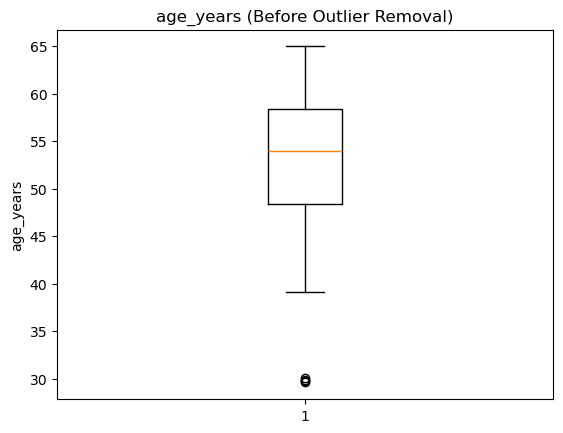

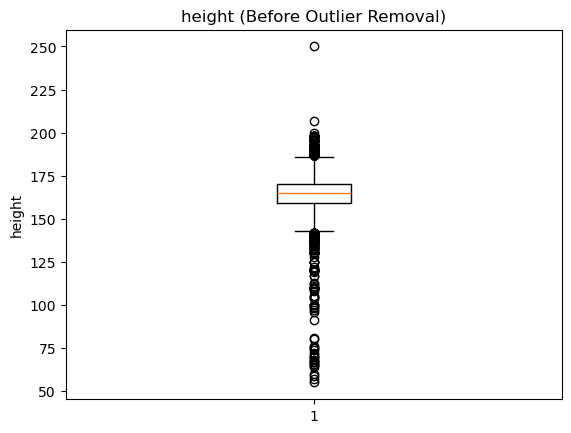

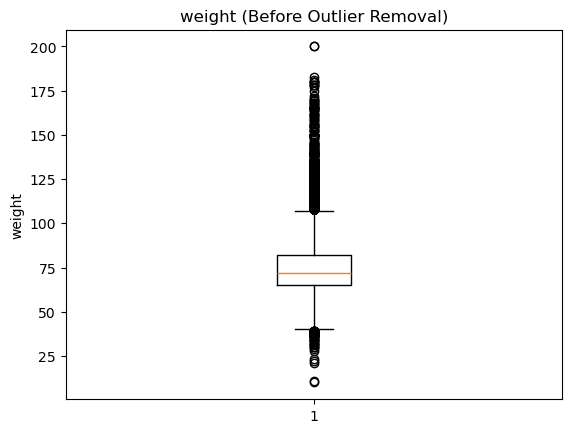

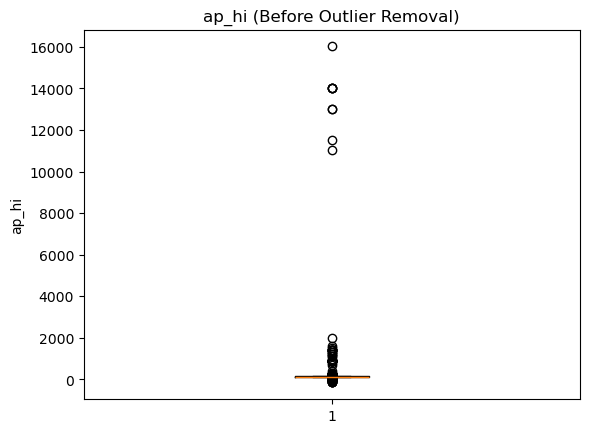

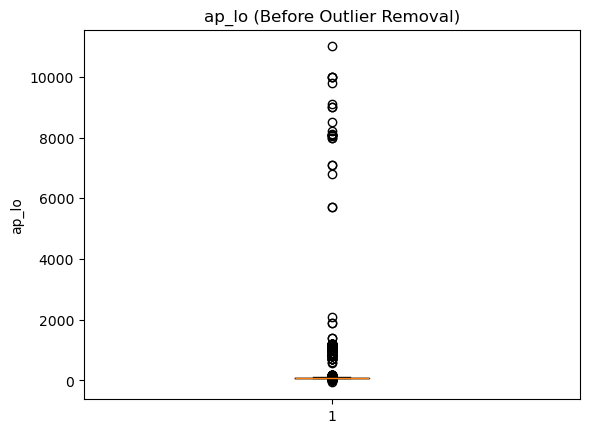

In [30]:
# Visualize before removing outliers

#Reload original dataset since cleaning has already occurred to remove outliers
df_original = pd.read_csv("cardio_train.csv", sep=";")

# Recreate derived feature
df_original["age_years"] = df_original["age"] / 365

for col in cols:
    plt.figure()
    plt.boxplot(df_original[col])
    plt.title(f"{col} (Before Outlier Removal)")
    plt.ylabel(col)


    plt.show()

In [31]:
# Remove outliers
df_clean = df.copy()

for col in cols:
    lower, upper = bounds[col]
    df_clean = df_clean[(df_clean[col] >= lower) & (df_clean[col] <= upper)]

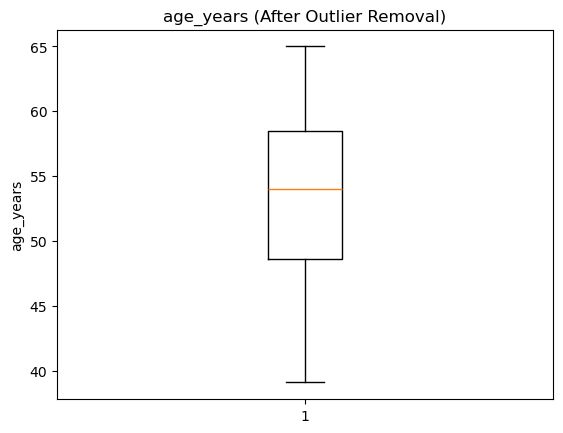

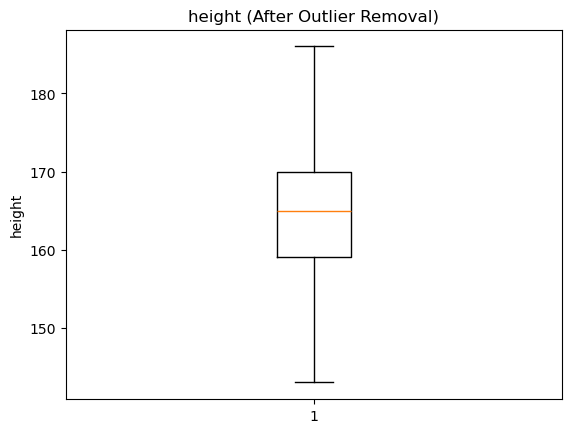

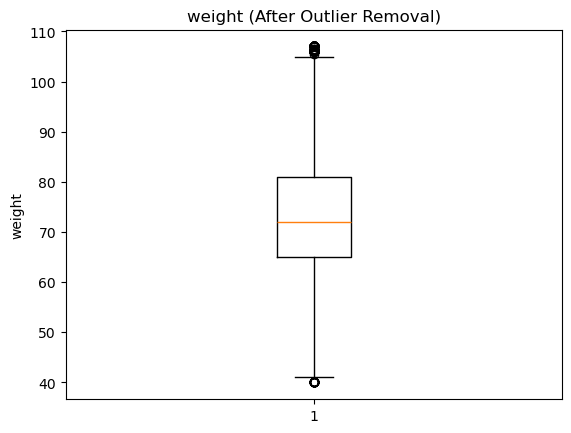

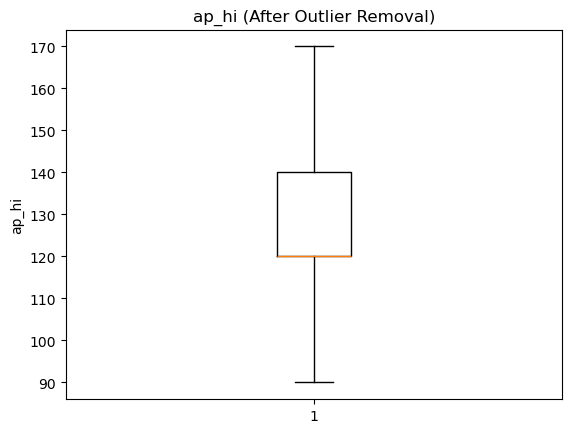

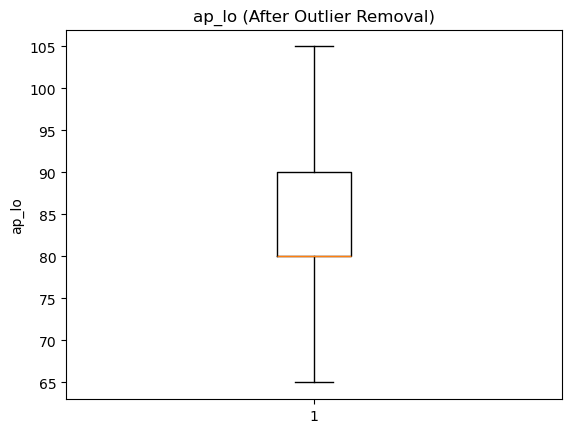

In [32]:
# Visualize after removing outliers
for col in cols:
    plt.figure()
    plt.boxplot(df_clean[col])
    plt.title(f"{col} (After Outlier Removal)")
    plt.ylabel(col)
    plt.show()

In [33]:
# Step 4: Principal Component Analysis

# Standardize the data
features = ["age_years", "height", "weight", "ap_hi", "ap_lo", "cholesterol", "gluc", "smoke", "alco", "active"]

X = df_clean[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [34]:
# Perform PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

In [35]:
# Check PC1 and PC2
loadings = pd.DataFrame(
    pca.components_[:2].T,
    columns=["PC1", "PC2"],
    index=features
)

print(loadings)

                  PC1       PC2
age_years    0.263540 -0.230291
height       0.055160  0.518633
weight       0.328689  0.301084
ap_hi        0.559035 -0.021542
ap_lo        0.537435  0.002254
cholesterol  0.365014 -0.198325
gluc         0.273759 -0.195171
smoke        0.061711  0.538737
alco         0.078251  0.466700
active       0.000199  0.037334


[0.20833895 0.15400844 0.1300005  0.11073828 0.09891756]


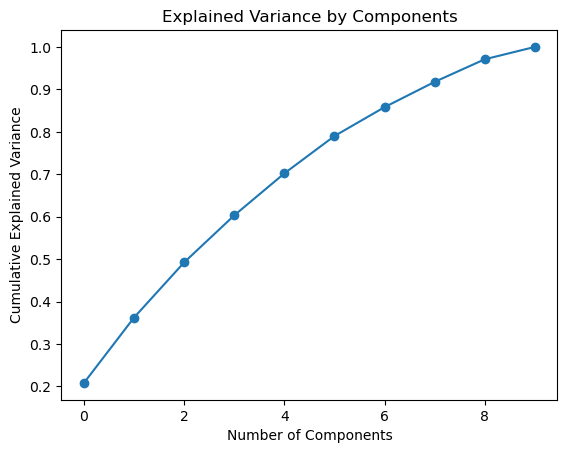

In [36]:
#Explained Variance
explained_variance= pca.explained_variance_ratio_
print(explained_variance[:5])

plt.figure()
plt.plot(np.cumsum(explained_variance), marker='o')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Explained Variance by Components")
plt.show()

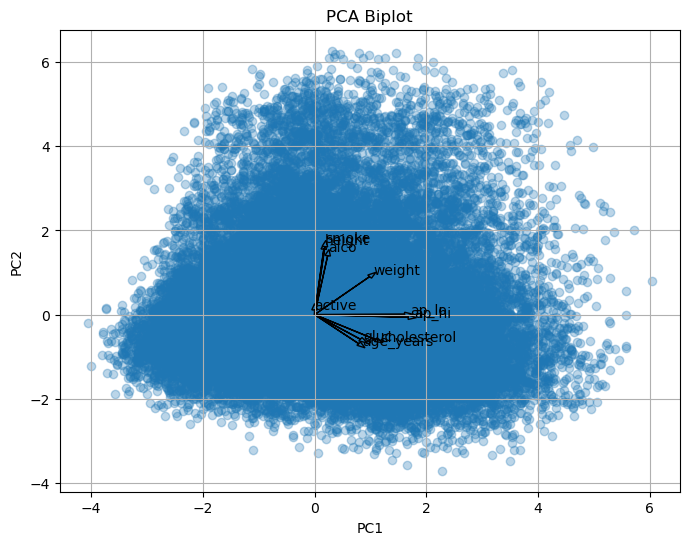

In [37]:
# Biplot (PC1 vs PC2)
plt.figure(figsize=(8,6))

# Scatter plot of observations
plt.scatter(X_pca[:,0], X_pca[:,1], alpha=0.3)

# Feature vectors
for i, feature in enumerate(features):
    plt.arrow(0, 0, 
              pca.components_[0, i]*3,
              pca.components_[1, i]*3,
              head_width=0.1)
    plt.text(pca.components_[0, i]*3.2, 
            pca.components_[1, i]*3.2, 
            feature)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Biplot")
plt.grid()
plt.show()

In [38]:
# Part 2: Statistical Study
# Step 5: MOM and MLE Estimation
# Suppose X1, X2, . . . , Xn ∼ N(μ, σ2) are independent observations from a normal distribution. Given the sample data: 2.1, 1.9, 2.5, 1.7, 2.0

data = np.array([2.1, 1.9, 2.5, 1.7, 2.0])

n = len(data)

# Methods of Moments (MoM)

mu_mom = np.mean(data)
var_mom = np.mean((data - mu_mom)**2)

# Maximum Likelihood Estimation (MLE)

mu_mle = np.mean(data)
var_mle = np.sum((data - mu_mle)**2) / n

# Print results

print("Method of Moments Estimates:")
print("mu (MoM):", mu_mom)
print("Variance (MoM):", var_mom)

print("\nMaximum Likelhood Estimates:")
print("mu (MLE):", mu_mle)
print("variance (MLE):", var_mle)

Method of Moments Estimates:
mu (MoM): 2.04
Variance (MoM): 0.0704

Maximum Likelhood Estimates:
mu (MLE): 2.04
variance (MLE): 0.0704


In [39]:
# Step 6: Monte Carlo Simulation

# Estimate P(X > 1)
# 10,000 samples
n1 = 10000
samples1 = np.random.normal(0, 1, n1)

prob_est_10k = np.mean(samples1 > 1)

print("Estimated P(X > 1) with 10,000 samples:", prob_est_10k)

# 100,000 samples
n2 = 100000
samples2 = np.random.normal(0, 1, n2)

prob_est_100k = np.mean(samples2 > 1)

print("Estimated P(X > 1) with 100,000 samples:", prob_est_100k)

# True Value
true_value = 0.1587
print("True value (approx):", true_value)

# Monte Carlo for f(x) = (x - 3)^2

f_10k = np.mean((samples1 - 3)**2)
f_100k = np.mean((samples2 - 3)**2)

print("\nEstimate of E[(X - 3)^2] with 10,000 samples:", f_10k)
print("Estimate of E[(X - 3)^2] with 100,000 samples:", f_100k)

Estimated P(X > 1) with 10,000 samples: 0.1635
Estimated P(X > 1) with 100,000 samples: 0.15892
True value (approx): 0.1587

Estimate of E[(X - 3)^2] with 10,000 samples: 10.00351485611572
Estimate of E[(X - 3)^2] with 100,000 samples: 9.984153640014057


Iteration | x value
    1     | 0.6000
    2     | 1.0800
    3     | 1.4640
    4     | 1.7712
    5     | 2.0170

Final estimate of x: 2.01696
True minimum x = 3


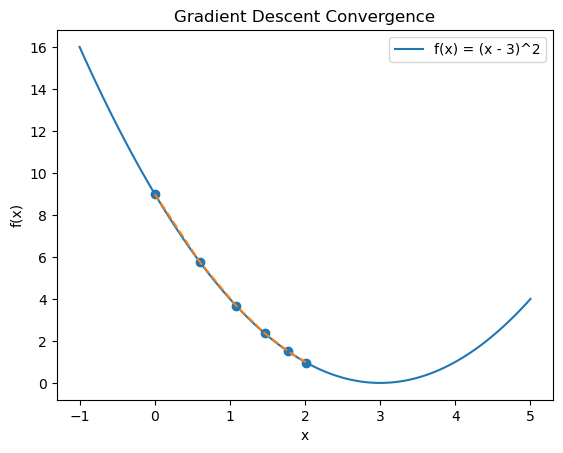

In [40]:
# Step 7: Gradient Descent Optimization

# Define function and derivative
def f(x):
    return (x - 3)**2

def grad_f(x):
    return 2 * (x - 3)

# Parameters
# Initial value
x = 0
# Learning rate
alpha = 0.1
iterations = 5

# Store values for tracking
x_values = [x]

print("Iteration | x value")

for i in range(iterations):
    x = x - alpha * grad_f(x)
    x_values.append(x)
    print(f"{i+1:^9} | {x:.4f}")

# Final estimate
print("\nFinal estimate of x:", x)
print("True minimum x = 3")

# Plot the function + descent

x_plot = np.linspace(-1, 5, 100)
y_plot = f(x_plot)

plt.figure()

# Plot function
plt.plot(x_plot, y_plot, label = "f(x) = (x - 3)^2")

# Plot gradient descent steps
y_values = [f(val) for val in x_values]
plt.scatter(x_values, y_values)

# Connect steps
plt.plot(x_values, y_values, linestyle="--")

plt.title("Gradient Descent Convergence")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()

plt.show()